In [10]:
import kagglehub
import json
import os

# ── Download dataset ───────────────────────────────────────────
path = kagglehub.dataset_download(
    "alienxc137/earthvqa-semantic-segmentation-visual-question-ans"
)
print("Downloaded to:", path)

# ── Paths ──────────────────────────────────────────────────────
BASE           = path
QA_DIR         = os.path.join(BASE, "2024EarthVQA", "2024EarthVQA")
TRAIN_IMG_DIR  = os.path.join(BASE, "Train-003", "Train", "images_png")
TRAIN_MASK_DIR = os.path.join(BASE, "Train-003", "Train", "masks_png")
VAL_IMG_DIR    = os.path.join(BASE, "Val-002", "Val", "images_png")
VAL_MASK_DIR   = os.path.join(BASE, "Val-002", "Val", "masks_png")
TEST_IMG_DIR   = os.path.join(BASE, "Test-001", "images_png")

# ── Load QA JSONs ──────────────────────────────────────────────
with open(os.path.join(QA_DIR, "Train_QA.json")) as f:
    train_qa_raw = json.load(f)
with open(os.path.join(QA_DIR, "Val_QA.json")) as f:
    val_qa_raw = json.load(f)
with open(os.path.join(QA_DIR, "Test_QA.json")) as f:
    test_qa_raw = json.load(f)

# ── Verify ─────────────────────────────────────────────────────
print("Train images exist:", os.path.exists(TRAIN_IMG_DIR))
print("Val images exist:  ", os.path.exists(VAL_IMG_DIR))
print("Test images exist: ", os.path.exists(TEST_IMG_DIR))

first_key = list(train_qa_raw.keys())[0]
print("\nFirst image:", first_key)
print("QA pairs:   ", len(train_qa_raw[first_key]))
print("Sample QA:  ", train_qa_raw[first_key][0])

print("\nTrain images:", len(train_qa_raw))
print("Val images:  ", len(val_qa_raw))
print("Test images: ", len(test_qa_raw))

Downloaded to: C:\Users\User\.cache\kagglehub\datasets\alienxc137\earthvqa-semantic-segmentation-visual-question-ans\versions\1
Train images exist: True
Val images exist:   True
Test images exist:  True

First image: 275.png
QA pairs:    29
Sample QA:   {'Type': 'Basic Judging', 'Question': 'Are there any buildings in this scene?', 'Answer': 'Yes'}

Train images: 2522
Val images:   1669
Test images:  1809


Train triplets : 88166
Val triplets   : 57202
Test triplets  : 63216

--- Sample triplets ---
[0] Image: 275.png
     Type : Basic Judging
     Q    : Are there any buildings in this scene?
     A    : Yes

[1] Image: 275.png
     Type : Basic Counting
     Q    : What is the area of buildings?
     A    : 0%-10%

[2] Image: 275.png
     Type : Basic Judging
     Q    : Are there any roads in this scene?
     A    : Yes



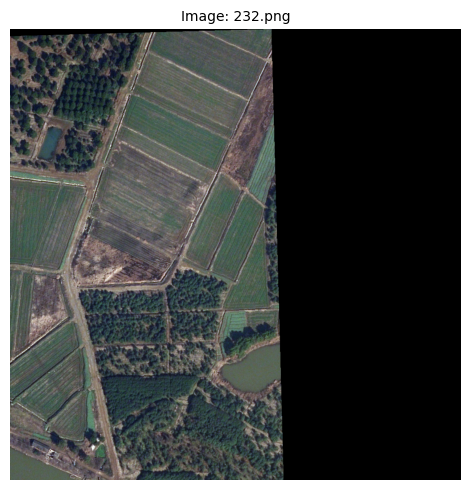


All 29 QA pairs for 232.png:
  Q1: Are there any buildings in this scene?
  A1: Yes
  Q2: What is the area of buildings?
  A2: 0%-10%
  Q3: Are there any roads in this scene?
  A3: Yes
  Q4: What is the area of roads?
  A4: 0%-10%
  Q5: Is there any water in this scene?
  A5: Yes
  Q6: What is the area of water?
  A6: 0%-10%
  Q7: Is there any barren in this scene?
  A7: Yes
  Q8: What is the area of barren?
  A8: 0%-10%
  Q9: Is there any forest in this scene?
  A9: Yes
  Q10: What is the area of the forest?
  A10: 10%-20%
  Q11: Is there any agriculture in this scene?
  A11: Yes
  Q12: What is the area of agriculture?
  A12: 20%-30%
  Q13: Are there any playgrounds in this scene?
  A13: No
  Q14: What is the area of playgrounds?
  A14: 0%-10%
  Q15: Is there any residential land in this scene?
  A15: No
  Q16: Is there any woodland in this scene?
  A16: Yes
  Q17: Is there any industrial land in this scene?
  A17: No
  Q18: Is it a rural or urban scene?
  A18: Rural
  Q19: Is there 

In [11]:
import json
import os
from PIL import Image
import matplotlib.pyplot as plt

# ── Only this line changes from Kaggle version ─────────────────
BASE = r"C:\Users\User\.cache\kagglehub\datasets\alienxc137\earthvqa-semantic-segmentation-visual-question-ans\versions\1"

QA_DIR         = f"{BASE}/2024EarthVQA/2024EarthVQA"
TRAIN_IMG_DIR  = f"{BASE}/Train-003/Train/images_png"
TRAIN_MASK_DIR = f"{BASE}/Train-003/Train/masks_png"
VAL_IMG_DIR    = f"{BASE}/Val-002/Val/images_png"
VAL_MASK_DIR   = f"{BASE}/Val-002/Val/masks_png"
TEST_IMG_DIR   = f"{BASE}/Test-001/images_png"

with open(f"{QA_DIR}/Train_QA.json") as f:
    train_qa_raw = json.load(f)
with open(f"{QA_DIR}/Val_QA.json") as f:
    val_qa_raw = json.load(f)
with open(f"{QA_DIR}/Test_QA.json") as f:
    test_qa_raw = json.load(f)

def flatten_qa(qa_raw):
    triplets = []
    for image_id, qa_pairs in qa_raw.items():
        for pair in qa_pairs:
            triplets.append({
                'image_id': image_id,
                'type':     pair['Type'],
                'question': pair['Question'],
                'answer':   str(pair['Answer'])
            })
    return triplets

train_triplets = flatten_qa(train_qa_raw)
val_triplets   = flatten_qa(val_qa_raw)
test_triplets  = flatten_qa(test_qa_raw)

train_images    = [t['image_id'] for t in train_triplets]
train_questions = [t['question'] for t in train_triplets]
train_answers   = [t['answer']   for t in train_triplets]
train_types     = [t['type']     for t in train_triplets]
val_images      = [t['image_id'] for t in val_triplets]
val_questions   = [t['question'] for t in val_triplets]
val_answers     = [t['answer']   for t in val_triplets]

print(f"Train triplets : {len(train_triplets)}")
print(f"Val triplets   : {len(val_triplets)}")
print(f"Test triplets  : {len(test_triplets)}")

print("\n--- Sample triplets ---")
for i in range(3):
    print(f"[{i}] Image: {train_images[i]}")
    print(f"     Type : {train_types[i]}")
    print(f"     Q    : {train_questions[i]}")
    print(f"     A    : {train_answers[i]}")
    print()

sample_image_id = train_images[600]
sample_img      = Image.open(f"{TRAIN_IMG_DIR}/{sample_image_id}")
all_qa_for_image = [(t['question'], t['answer'])
                    for t in train_triplets
                    if t['image_id'] == sample_image_id]

plt.figure(figsize=(5, 5))
plt.imshow(sample_img)
plt.axis('off')
plt.title(f"Image: {sample_image_id}", fontsize=10)
plt.tight_layout()
plt.show()

print(f"\nAll {len(all_qa_for_image)} QA pairs for {sample_image_id}:")
for i, (q, a) in enumerate(all_qa_for_image):
    print(f"  Q{i+1}: {q}")
    print(f"  A{i+1}: {a}")

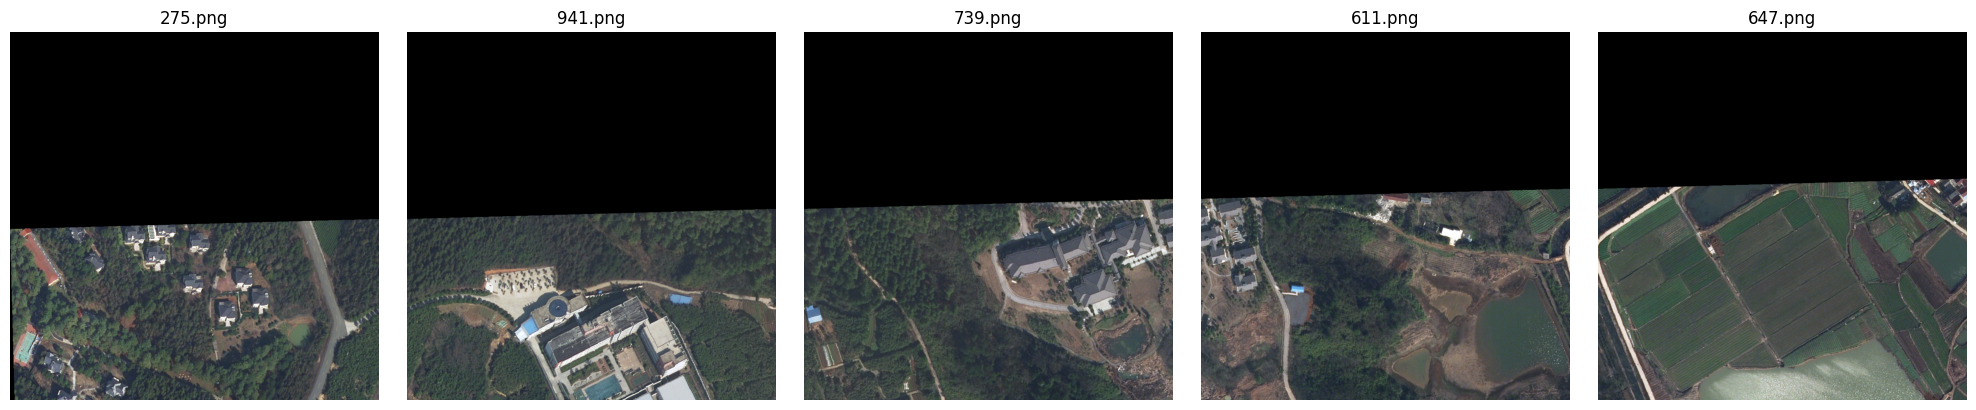

In [12]:
# Check a few different images
test_images = list(train_qa_raw.keys())[:5]


fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, img_id in enumerate(test_images):
    img = Image.open(f"{TRAIN_IMG_DIR}/{img_id}").convert('RGB')
    axes[i].imshow(img)
    axes[i].set_title(img_id)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [13]:
import json
import os
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer
import torchvision.transforms as T

# ── 1. Answer Vocabulary ──────────────────────────────────────
def build_answer_vocab(qa_raw):
    answers = set()
    for qa_pairs in qa_raw.values():
        for pair in qa_pairs:
            answers.add(str(pair['Answer']))
    ans2idx = {a: i for i, a in enumerate(sorted(answers))}
    idx2ans = {i: a for a, i in ans2idx.items()}
    return ans2idx, idx2ans

# ── 2. Generative Target ──────────────────────────────────────
def format_generative_target(answer, question_type):
    return answer

# ── 3. Dataset Class ──────────────────────────────────────────
class EarthVQADataset(Dataset):
    def __init__(self, qa_raw, image_dir, mask_dir=None,
                 ans2idx=None, img_size=256, max_seq_len=128):

        self.image_dir   = image_dir
        self.mask_dir    = mask_dir
        self.ans2idx     = ans2idx
        self.max_seq_len = max_seq_len
        self.img_size    = img_size

        # Flatten JSON to triplets
        self.triplets = []
        for image_id, qa_pairs in qa_raw.items():
            for pair in qa_pairs:
                self.triplets.append({
                    'image_id': image_id,
                    'type':     pair['Type'],
                    'question': pair['Question'],
                    'answer':   str(pair['Answer'])
                })

        # Image transform
        self.img_transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
        ])

        # Mask transform
        self.mask_transform = T.Compose([
            T.Resize((img_size, img_size),
                     interpolation=T.InterpolationMode.NEAREST),
        ])

        # Tokenizer
        self.tokenizer = DistilBertTokenizer.from_pretrained('bert-base-uncased')
        self.tokenizer.add_special_tokens({'sep_token': '[SEP]'})

    def __len__(self):
        return len(self.triplets)

    def __getitem__(self, idx):
        item = self.triplets[idx]

        # ── IMAGE ─────────────────────────────────────────────
        img_path = os.path.join(self.image_dir, item['image_id'])
        image    = Image.open(img_path).convert('RGB')
        image    = self.img_transform(image)             # [3, 256, 256]

        # ── QUESTION ──────────────────────────────────────────
        q_encoded = self.tokenizer(
            item['question'],
            padding='max_length',
            truncation=True,
            max_length=64,
            return_tensors='pt'
        )

        # ── GENERATIVE TARGET ─────────────────────────────────
        gen_text       = format_generative_target(item['answer'], item['type'])
        target_encoded = self.tokenizer(
            gen_text,
            padding='max_length',
            truncation=True,
            max_length=self.max_seq_len,
            return_tensors='pt'
        )

        # ── MASK ──────────────────────────────────────────────
        mask = torch.zeros(self.img_size, self.img_size, dtype=torch.long)
        if self.mask_dir:
            mask_path = os.path.join(self.mask_dir, item['image_id'])
            if os.path.exists(mask_path):
                m    = Image.open(mask_path)
                m    = self.mask_transform(m)
                mask = torch.from_numpy(np.array(m)).long()  # [256, 256]

        # ── ANSWER INDEX ──────────────────────────────────────
        ans_idx = self.ans2idx.get(item['answer'], 0) if self.ans2idx else 0

        return {
            'image_pixel_values': image,                                    # [3, 256, 256]
            'question_input_ids': q_encoded['input_ids'].squeeze(0),        # [64]
            'question_attn_mask': q_encoded['attention_mask'].squeeze(0),   # [64]
            'decoder_input_ids':  target_encoded['input_ids'].squeeze(0),   # [128]
            'decoder_labels':     target_encoded['input_ids'].squeeze(0).clone(), # [128]
            'relational_mask':    mask,                                     # [256, 256]
            'answer_class_idx':   torch.tensor(ans_idx, dtype=torch.long),  # scalar
            'image_id':           item['image_id'],
            'raw_explanation':    gen_text
        }

# ── 4. Build Vocab ────────────────────────────────────────────
ans2idx, idx2ans = build_answer_vocab(train_qa_raw)
print(f"Total unique answers: {len(ans2idx)}")

# ── 5. Datasets ───────────────────────────────────────────────
train_dataset = EarthVQADataset(
    train_qa_raw, TRAIN_IMG_DIR, TRAIN_MASK_DIR, ans2idx, img_size=256
)
val_dataset   = EarthVQADataset(
    val_qa_raw, VAL_IMG_DIR, VAL_MASK_DIR, ans2idx, img_size=256
)
test_dataset  = EarthVQADataset(
    test_qa_raw, TEST_IMG_DIR, mask_dir=None, ans2idx=ans2idx, img_size=256
)

# ── 6. DataLoaders ────────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False, num_workers=0)

# ── 7. Verify ─────────────────────────────────────────────────
print(f"Train samples: {len(train_dataset)}")
print(f"Val samples:   {len(val_dataset)}")
print(f"Test samples:  {len(test_dataset)}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

batch = next(iter(train_loader))
print(f"\nImage shape:      {batch['image_pixel_values'].shape}")   # [1, 3, 256, 256]
print(f"Question IDs:     {batch['question_input_ids'].shape}")    # [1, 64]
print(f"Mask shape:       {batch['relational_mask'].shape}")       # [1, 256, 256]
print(f"Answer class idx: {batch['answer_class_idx']}")
print(f"Sample answer:    {batch['raw_explanation'][0]}")

Total unique answers: 147


Train samples: 88166
Val samples:   57202
Test samples:  63216
Train batches: 5511
Val batches:   3576
Test batches:  3951

Image shape:      torch.Size([16, 3, 256, 256])
Question IDs:     torch.Size([16, 64])
Mask shape:       torch.Size([16, 256, 256])
Answer class idx: tensor([ 75, 146, 146,  17, 146,   1,   0, 146,  17,  10,  59,  23,   0,  57,
          1,  19])
Sample answer:    There are residential, and commercial areas


In [14]:
import torch
print(torch.cuda.is_available())       # should print True
print(torch.version.cuda)              # should print CUDA version
print(torch.cuda.get_device_name(0))   # should print GPU name

True
12.1
NVIDIA GeForce RTX 3060 Ti


In [15]:
# Check exact CUDA and Python version first
import torch
print("CUDA version:", torch.version.cuda)
import sys
print("Python version:", sys.version)

CUDA version: 12.1
Python version: 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]


In [16]:
print(f"VRAM free: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1e9:.2f} GB")

VRAM free: 8.59 GB


In [17]:
from torch.utils.checkpoint import checkpoint